# Credit Risk Decision Lab - Analysis Notebook

## Problem Definition
This notebook supports an interactive credit-risk product for ACC102 Track 4.
The analytical goal is to estimate loan default risk and translate model output into a practical approval recommendation.

## Dataset and Source
- Dataset: Credit Risk Dataset (Kaggle)
- Link: https://www.kaggle.com/datasets/laotse/credit-risk-dataset?resource=download
- Access date: 15 April 2026
- Target: `loan_status` (renamed to `default_flag` in processed data)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = '../credit_risk_dataset.csv/credit_risk_dataset.csv'
CLEAN_PATH = '../data/processed/loan_clean.csv'
CLEAN_REPORT_PATH = '../data/processed/clean_report.csv'
METRICS_PATH = '../models/model_metrics.json'
COMPARE_PATH = '../models/model_comparison.csv'

In [2]:
raw_df = pd.read_csv(RAW_PATH)
clean_df = pd.read_csv(CLEAN_PATH)
clean_report = pd.read_csv(CLEAN_REPORT_PATH)
model_comparison = pd.read_csv(COMPARE_PATH)

print('Raw shape:', raw_df.shape)
print('Clean shape:', clean_df.shape)
print('Default rate (clean):', round(clean_df['default_flag'].mean(), 4))

Raw shape: (32581, 12)
Clean shape: (32416, 12)
Default rate (clean): 0.2187


## Cleaning Evidence

In [3]:
clean_report

,step,value
0,raw_shape,32581x12
1,drop_duplicates,165
2,drop_target_na,0
3,age_lt_18_to_nan,0
4,age_gt_100_to_nan,5
5,income_non_positive_to_nan,0
6,emp_length_negative_to_nan,0
7,emp_length_gt_60_to_nan,2
8,loan_amnt_non_positive_to_nan,0
9,loan_int_rate_out_of_range_to_nan,0


## Descriptive Analysis

In [4]:
summary_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate']
clean_df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32416.0,27.730102,6.210006,20.00,23.00,26.00,30.00,94.00
person_income,32416.0,66091.640826,62015.580269,4000.00,38542.00,55000.00,79218.00,6000000.00
person_emp_length,32416.0,4.761538,3.983588,0.00,2.00,4.00,7.00,41.00
loan_amnt,32416.0,9593.845632,6322.730241,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,32416.0,11.014662,3.083050,5.42,8.49,10.99,13.11,23.22


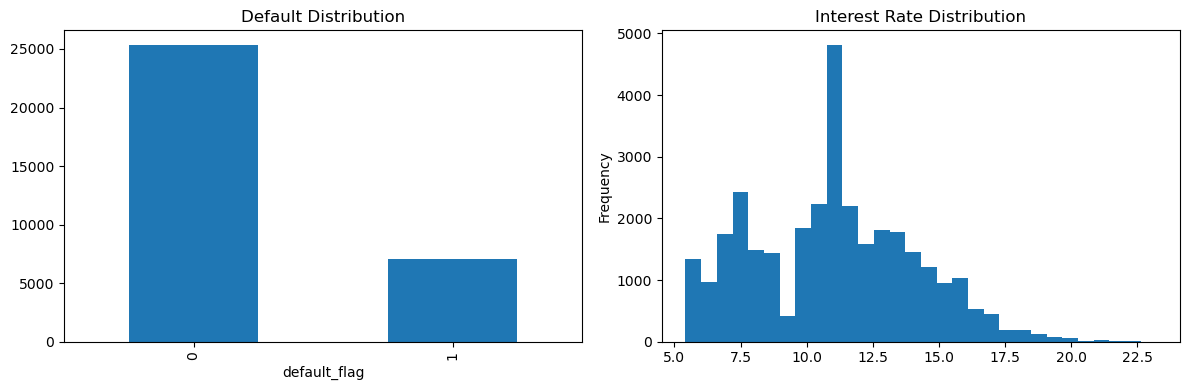

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clean_df['default_flag'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Default Distribution')
clean_df['loan_int_rate'].plot(kind='hist', bins=30, ax=axes[1], title='Interest Rate Distribution')
plt.tight_layout()

## Model Results

In [6]:
with open(METRICS_PATH, 'r', encoding='utf-8') as f:
    metrics = json.load(f)

print('Best model:', metrics['best_model'])
pd.DataFrame(metrics['models']).T

Best model: random_forest


,accuracy,precision,recall,f1,roc_auc,n_train,n_test,target_rate_train
logistic,0.852560,0.765517,0.469676,0.582168,0.852832,25932.0,6484.0,0.218687
random_forest,0.919803,0.942801,0.674189,0.786184,0.919206,25932.0,6484.0,0.218687


In [7]:
model_comparison

,model_name,accuracy,precision,recall,f1,roc_auc,n_train,n_test,target_rate_train
0,logistic,0.852560,0.765517,0.469676,0.582168,0.852832,25932.0,6484.0,0.218687
1,random_forest,0.919803,0.942801,0.674189,0.786184,0.919206,25932.0,6484.0,0.218687


## Interpretation and Product Decision Logic

- Random Forest is selected as the best model in this version.
- The app exposes threshold control to show policy trade-offs.
- Lower threshold captures more risky users but can increase false rejection.
- Higher threshold improves precision/accuracy but may miss some risky users.

This supports the Track 4 goal: a user-facing interactive Python product with substantive analytical work.